In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import matplotlib

import multiprocessing
import os
import time

from scipy.optimize import curve_fit 

In [ ]:
f, theta, x1, x2, x3, x4, u, v, tl1, tl2, tl3, tl4, tl1p, tl2p, tl3p, tl4p = symbols('f theta x1 x2 x3 x4 u v tl1 tl2 tl3 tl4 tl1p tl2p tl3p tl4p')

def MLens(f):
    return Matrix([[1,0,0],[-1/f,1,0],[0,0,1]])

def ElemTR(elem,theta,u,v):
        return Matrix([[1,-u,-v],[0,1,0],[0,0,1]])*Matrix([[1,0,0],[0,cos(theta),sin(theta)],[0,-sin(theta),cos(theta)]])*elem*Matrix([[1,0,0],[0,cos(-theta),sin(-theta)],[0,-sin(-theta),cos(-theta)]])*Matrix([[1,u,v],[0,1,0],[0,0,1]])

class opelements():
    def __init__(self, elem_type, f, tl0, tl, u, v):
        self.pos_x=u
        self.pos_y=v
        self.tl0=tl0
        self.tl=tl
        self.elem_type=elem_type
        if self.elem_type=='Mirror':
            self.MRefl=Matrix([[-1,0,0],[0,1,0],[0,0,-1]])
            self.elem=ElemTR(self.MRefl, self.tl0 + self.tl, self.pos_x, self.pos_y)
        elif self.elem_type=='Lens':
            self.MLens=Matrix([[1,0,0],[-1/f,1,0],[0,0,1]])
            self.elem=ElemTR(self.MLens, self.tl0 + self.tl, self.pos_x, self.pos_y)
        else:
            print('This type is undefined!')

def plot_ray_solver(elem_list,ray_in, x1, x5):
    ray_list=[ray_in]

    for i in range(len(elem_list)):
        ray_cache=ray_in
        for j in range(i+1):
            ray_cache=elem_list[j].elem*ray_cache
        ray_list.append(ray_cache)
    xy_solve=[[0,0.2]]

    for i in range(len(ray_list)-1):
        ray_cache1=ray_list[i]
        ray_cache2=ray_list[i+1]
        #print(ray_cache1)
        a1=np.round(float(ray_cache1[1]),10)
        a2=np.round(float(ray_cache2[1]),10)
        b1=np.round(float(ray_cache1[2]),10)
        b2=np.round(float(ray_cache2[2]),10)
        c1=np.round(float(ray_cache1[0]),10)
        c2=np.round(float(ray_cache2[0]),10)
        x_solve=(b2*c1-b1*c2)/(a2*b1-a1*b2)
        y_solve=(a1*c2-a2*c1)/(a2*b1-a1*b2)
        xy_solve.append([x_solve,y_solve])

    xy_solve.append([x1+x5,0])

    return xy_solve

def get_var_name(var):
    for name, value in globals().items():
        if value is var:
            return name

def Rotation_matrix(theta):
        return np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

def ray_plotter(elem_list, elem_list_ref, ray_in, x0, y0, x1, x5, xy):
        #ray plotter
    xy_ray=plot_ray_solver(elem_list, ray_in, x1, x5)
    xy_ray_ref=plot_ray_solver(elem_list_ref, ray_in, x1, x5)

    fig,ax=plt.subplots(figsize=(6,6))
    plt.scatter(x0,y0,marker='x',color='r')
    for i in range(len(xy_ray)-1):
        if i==0:
            plt.plot([xy_ray[i][0], xy_ray[i+1][0]], [xy_ray[i][1], xy_ray[i+1][1]],'b',label='Light Ray')
            continue
        plt.plot([xy_ray[i][0], xy_ray[i+1][0]], [xy_ray[i][1], xy_ray[i+1][1]],'b')
        #print([xy_ray[i][0], xy_ray[i+1][0]], [xy_ray[i][1], xy_ray[i+1][1]])
        plt.axis('equal')
    for i in range(len(xy_ray_ref)-1):
        if i==0:
            plt.plot([xy_ray_ref[i][0], xy_ray_ref[i+1][0]], [xy_ray_ref[i][1], xy_ray_ref[i+1][1]],'g--',label='Reference Ray')
            continue
        plt.plot([xy_ray_ref[i][0], xy_ray_ref[i+1][0]], [xy_ray_ref[i][1], xy_ray_ref[i+1][1]],'g--')

    #Element plotter
    element_length=0.025
    pivot_size=5
    for i in range(len(elem_list_ref)):
        if elem_list_ref[i].elem_type=='Mirror':
            point1=np.array([[0],[element_length]])
            point1=(Rotation_matrix(-float(elem_list_ref[i].tl0+elem_list_ref[i].tl))@point1)+np.array([[elem_list_ref[i].pos_x],[elem_list_ref[i].pos_y]])
            point2=np.array([[0],[-element_length]])
            point2=(Rotation_matrix(-float(elem_list_ref[i].tl0+elem_list_ref[i].tl))@point2)+np.array([[elem_list_ref[i].pos_x],[elem_list_ref[i].pos_y]])
            cache_array=np.concatenate((point1,point2),1)
            if i==0:
                ax.plot(cache_array[0,:],cache_array[1,:],linestyle='dashed',color='darkgray',lw=1,label='Reference Mirror')
                continue
            ax.plot(cache_array[0,:],cache_array[1,:],linestyle='dashed',color='darkgray',lw=1)
            ax.scatter(elem_list_ref[i].pos_x,elem_list_ref[i].pos_y,color='k',s=pivot_size)
        elif elem_list_ref[i].elem_type=='Lens':
            point1=np.array([[0],[element_length/2]])
            point1=(Rotation_matrix(-float(elem_list_ref[i].tl0+elem_list_ref[i].tl))@point1)+np.array([[elem_list_ref[i].pos_x],[elem_list_ref[i].pos_y]])
            point2=np.array([[0],[-element_length/2]])
            point2=(Rotation_matrix(-float(elem_list_ref[i].tl0+elem_list_ref[i].tl))@point2)+np.array([[elem_list_ref[i].pos_x],[elem_list_ref[i].pos_y]])
            cache_array=np.concatenate((point1,point2),1)
            ax.plot(cache_array[0,:],cache_array[1,:],linestyle='dashed',color='darkgray',lw=1)

    for i in range(len(elem_list)):
        if elem_list[i].elem_type=='Mirror':
            point1=np.array([[0],[element_length]])
            point1=(Rotation_matrix(-float(elem_list[i].tl0+elem_list[i].tl))@point1)+np.array([[elem_list[i].pos_x],[elem_list[i].pos_y]])
            point2=np.array([[0],[-element_length]])
            point2=(Rotation_matrix(-float(elem_list[i].tl0+elem_list[i].tl))@point2)+np.array([[elem_list[i].pos_x],[elem_list[i].pos_y]])
            cache_array=np.concatenate((point1,point2),1)
            if i==0:
                ax.plot(cache_array[0,:],cache_array[1,:],'-k',lw=1,label='Mirror')
                continue
            ax.plot(cache_array[0,:],cache_array[1,:],'-k',lw=1)
            ax.scatter(elem_list[i].pos_x,elem_list[i].pos_y,color='k',s=pivot_size)
        elif elem_list[i].elem_type=='Lens':
            point1=np.array([[0],[element_length/2]])
            point1=(Rotation_matrix(-float(elem_list[i].tl0+elem_list[i].tl))@point1)+np.array([[elem_list[i].pos_x],[elem_list[i].pos_y]])
            point2=np.array([[0],[-element_length/2]])
            point2=(Rotation_matrix(-float(elem_list[i].tl0+elem_list[i].tl))@point2)+np.array([[elem_list[i].pos_x],[elem_list[i].pos_y]])
            cache_array=np.concatenate((point1,point2),1)
            ax.plot(cache_array[0,:],cache_array[1,:],'*-k',lw=1)

    # Change major ticks to show every 20.
    ax.xaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    # Change minor ticks to show every 5. (20/4 = 5)
    ax.xaxis.set_minor_locator(AutoMinorLocator(0.01))
    ax.yaxis.set_minor_locator(AutoMinorLocator(0.01))
    ax.minorticks_on()
    ax.grid(which='major', color='#CCCCCC', linestyle='--')
    ax.grid(which='minor', color='#CCCCCC', linestyle=':')
    ax.legend()
    if xy==0:
        plt.title('Layout of Optical Elements in x axis')
    elif xy==1:
        plt.title('Layout of Optical Elements in y axis')
    plt.xlabel('X/m')
    plt.ylabel('Y/m')

    #plt.xlim([0.05, 0.10])
    #plt.ylim([-0.025, 0.025])

    plt.show()

In [4]:
def four_mirror_sweep_offset(tl1_n,x1,x2,x4,x5,dy0,dy1,xy,plot_switch):

    #definition of parameters
    #x1 = 0.09
    #x2 = 0.065
    #dy0 = 0.05078
    
    #focal length
    fl = 0.05
    x3 = dy0+dy1
    #x4 = 0.025
    #x5 = 0.1
    x0 = x1
    y0 = x2 + dy0

    #using polaris mount
    offset=16.51e-3
    #offset=0

    Mrr1_pos_x=0-np.sqrt(2)*offset/2
    Mrr1_pos_y=0+np.sqrt(2)*offset/2
    Mrr2_pos_x=x1-np.sqrt(2)*offset/2
    Mrr2_pos_y=0-np.sqrt(2)*offset/2
    Mrr3_pos_x=x1+np.sqrt(2)*offset/2
    Mrr3_pos_y=x2 + x3 + x4+np.sqrt(2)*offset/2
    Mrr4_pos_x=x1 + x5+np.sqrt(2)*offset/2
    Mrr4_pos_y=x2 + x3 + x4-np.sqrt(2)*offset/2
    Ml1_pos_x=x1
    Ml1_pos_y=x2
    Ml2_pos_x=x1
    Ml2_pos_y=x2+x3

    Mrr1=opelements('Mirror',None, -np.pi/4, tl1, Mrr1_pos_x, Mrr1_pos_y)
    Mrr2=opelements('Mirror',None, np.pi/4, tl2, Mrr2_pos_x, Mrr2_pos_y)
    Mrr3=opelements('Mirror',None, np.pi/4, tl3, Mrr3_pos_x, Mrr3_pos_y)
    Mrr4=opelements('Mirror',None, -np.pi/4, tl4, Mrr4_pos_x, Mrr4_pos_y)
    Ml1=opelements('Lens',fl, -np.pi/2, 0, Ml1_pos_x, Ml1_pos_y)
    Ml2=opelements('Lens',fl, -np.pi/2, 0, Ml2_pos_x, Ml2_pos_y)

    Mrr1_ref=opelements('Mirror',None, -np.pi/4, 0, Mrr1_pos_x, Mrr1_pos_y)
    Mrr2_ref=opelements('Mirror',None, np.pi/4, 0, Mrr2_pos_x, Mrr2_pos_y)
    Mrr3_ref=opelements('Mirror',None, np.pi/4, 0, Mrr3_pos_x, Mrr3_pos_y)
    Mrr4_ref=opelements('Mirror',None, -np.pi/4, 0, Mrr4_pos_x, Mrr4_pos_y)

    elem_list=[Mrr1, Mrr2, Ml1, Ml2, Mrr3, Mrr4]
    elem_list_ref=[Mrr1_ref, Mrr2_ref, Ml1, Ml2, Mrr3_ref, Mrr4_ref]

    Mrr1.tl=tl1_n

    #angle solver
    ray_in=Matrix([[0],[1],[1e-10]])

    Mrr1.elem=Mrr1.elem.subs(tl1,Mrr1.tl)
    raymiddle = Ml1.elem * Mrr2.elem * Mrr1.elem * ray_in
    eqn = raymiddle[0] + raymiddle[1]*x0 + raymiddle[2]*y0
    Mrr2.tl=nsolve(eqn,tl2,0)
    Mrr2.elem=Mrr2.elem.subs(tl2,Mrr2.tl)
    raymiddle=raymiddle.subs(tl2,Mrr2.tl)
    rayfinal=Mrr4.elem * Mrr3.elem * Ml2.elem * raymiddle

    rayfinalref =Mrr4_ref.elem * Mrr3_ref.elem * Ml2.elem * Ml1.elem * Mrr2_ref.elem * Mrr1_ref.elem * ray_in
    
    eqn1 = rayfinal[1]*rayfinalref[0] - rayfinalref[1]*rayfinal[0]
    eqn2 = rayfinal[2]*rayfinalref[0] - rayfinalref[2]*rayfinal[0]

    result=nsolve((eqn1,eqn2),(tl3,tl4),(0,0))
    Mrr3.tl=result[0]
    Mrr4.tl=result[1]
    Mrr3.elem=Mrr3.elem.subs(tl3,Mrr3.tl)
    Mrr4.elem=Mrr4.elem.subs(tl4,Mrr4.tl)

    #ray plot
    if plot_switch==1:
        ray_plotter(elem_list, elem_list_ref, ray_in, x0, y0, x1, x5, xy)

    if xy==0:
        return [float(Mrr1.tl), float(Mrr2.tl), float(Mrr3.tl), float(Mrr4.tl)]
    elif xy==1:
        return [float(Mrr1.tl), -float(Mrr2.tl), float(Mrr3.tl), -float(Mrr4.tl)]

In [ ]:
def xy_compensation(tls,x1,x2,x4,x5,dy0,dy1,plot_switch):
    
    #definition of parameters
    
    tl1_x_n=tls[0][0]
    tl2_x_n=tls[0][1]
    tl3_x_n=tls[0][2]
    tl4_x_n=tls[0][3]
    tl1_y_n=tls[1][0]
    tl2_y_n=tls[1][1]
    tl3_y_n=tls[1][2]
    tl4_y_n=tls[1][3]

    y_dist_1=np.tan(tl1_y_n)*dist*1e-3*np.cos(tl1_x_n)*0.5
    y_dist_2=np.tan(tl2_y_n)*dist*1e-3*np.cos(tl2_x_n)*0.5
    y_dist_3=np.tan(tl3_y_n)*dist*1e-3*np.cos(tl3_x_n)*0.5
    y_dist_4=np.tan(tl4_y_n)*dist*1e-3*np.cos(tl4_x_n)*0.5

    fl = 0.05
    x3 = dy0+dy1
    x0 = x1
    y0 = x2 + dy0

    offset=16.51e-3
    #offset=0
    
    Mrr1_pos_x=0-np.sqrt(2)*offset/2+np.cos(abs(-np.pi/4+tl1_x_n))*y_dist_1
    Mrr1_pos_y=0+np.sqrt(2)*offset/2+np.sin(abs(-np.pi/4+tl1_x_n))*y_dist_1
    Mrr2_pos_x=x1-np.sqrt(2)*offset/2-np.cos(abs(np.pi/4+tl2_x_n))*y_dist_2
    Mrr2_pos_y=0-np.sqrt(2)*offset/2+np.sin(abs(np.pi/4+tl2_x_n))*y_dist_2
    Mrr3_pos_x=x1+np.sqrt(2)*offset/2+np.cos(abs(np.pi/4+tl3_x_n))*y_dist_3
    Mrr3_pos_y=x2 + x3 + x4+np.sqrt(2)*offset/2-np.sin(abs(np.pi/4+tl3_x_n))*y_dist_3
    Mrr4_pos_x=x1 + x5+np.sqrt(2)*offset/2-np.cos(abs(-np.pi/4+tl4_x_n))*y_dist_4
    Mrr4_pos_y=x2 + x3 + x4-np.sqrt(2)*offset/2-np.sin(abs(-np.pi/4+tl4_x_n))*y_dist_4

    Mrr1_pos_x_ref=0-np.sqrt(2)*offset/2
    Mrr1_pos_y_ref=0+np.sqrt(2)*offset/2
    Mrr2_pos_x_ref=x1-np.sqrt(2)*offset/2
    Mrr2_pos_y_ref=0-np.sqrt(2)*offset/2
    Mrr3_pos_x_ref=x1+np.sqrt(2)*offset/2
    Mrr3_pos_y_ref=x2 + x3 + x4+np.sqrt(2)*offset/2
    Mrr4_pos_x_ref=x1 + x5+np.sqrt(2)*offset/2
    Mrr4_pos_y_ref=x2 + x3 + x4-np.sqrt(2)*offset/2

    Ml1_pos_x=x1
    Ml1_pos_y=x2
    Ml2_pos_x=x1
    Ml2_pos_y=x2+x3

    Mrr1=opelements('Mirror',None, -np.pi/4+tl1_x_n, tl1p, Mrr1_pos_x, Mrr1_pos_y)
    Mrr2=opelements('Mirror',None, np.pi/4+tl2_x_n, tl2p, Mrr2_pos_x, Mrr2_pos_y)
    Mrr3=opelements('Mirror',None, np.pi/4+tl3_x_n, tl3p, Mrr3_pos_x, Mrr3_pos_y)
    Mrr4=opelements('Mirror',None, -np.pi/4+tl4_x_n, tl4p, Mrr4_pos_x, Mrr4_pos_y)
    Ml1=opelements('Lens',fl, -np.pi/2, 0, Ml1_pos_x, Ml1_pos_y)
    Ml2=opelements('Lens',fl, -np.pi/2, 0, Ml2_pos_x, Ml2_pos_y)

    Mrr1_ref=opelements('Mirror',None, -np.pi/4+tl1_x_n, 0, Mrr1_pos_x_ref, Mrr1_pos_y_ref)
    Mrr2_ref=opelements('Mirror',None, np.pi/4+tl2_x_n, 0, Mrr2_pos_x_ref, Mrr2_pos_y_ref)
    Mrr3_ref=opelements('Mirror',None, np.pi/4+tl3_x_n, 0, Mrr3_pos_x_ref, Mrr3_pos_y_ref)
    Mrr4_ref=opelements('Mirror',None, -np.pi/4+tl4_x_n, 0, Mrr4_pos_x_ref, Mrr4_pos_y_ref)

    elem_list=[Mrr1, Mrr2, Ml1, Ml2, Mrr3, Mrr4]
    elem_list_ref=[Mrr1_ref, Mrr2_ref, Ml1, Ml2, Mrr3_ref, Mrr4_ref]

    #angle solver
    ray_in=Matrix([[0],[1],[1e-10]])
    raymiddle = Ml1.elem * Mrr2.elem * Mrr1.elem * ray_in
    raymiddleref = Ml1.elem * Mrr2_ref.elem * Mrr1_ref.elem * ray_in

    eqn1 = raymiddle[1]*raymiddleref[0] - raymiddleref[1]*raymiddle[0]
    eqn2 = raymiddle[2]*raymiddleref[0] - raymiddleref[2]*raymiddle[0]
    result=nsolve((eqn1,eqn2),(tl1p,tl2p),(0,0))

    Mrr1.tl=result[0]
    Mrr2.tl=result[1]
    Mrr1.elem=Mrr1.elem.subs(tl1p,Mrr1.tl)
    Mrr2.elem=Mrr2.elem.subs(tl2p,Mrr2.tl)
    raymiddle=raymiddle.subs({tl1p:Mrr1.tl,tl2p:Mrr2.tl})
   
    rayfinal=Mrr4.elem * Mrr3.elem * Ml2.elem * raymiddle
    rayfinalref =Mrr4_ref.elem * Mrr3_ref.elem * Ml2.elem * Ml1.elem * Mrr2_ref.elem * Mrr1_ref.elem * ray_in

    eqn1 = rayfinal[1]*rayfinalref[0] - rayfinalref[1]*rayfinal[0]
    eqn2 = rayfinal[2]*rayfinalref[0] - rayfinalref[2]*rayfinal[0]

    result=nsolve((eqn1,eqn2),(tl3p,tl4p),(0,0))
    Mrr3.tl=result[0]
    Mrr4.tl=result[1]
    Mrr3.elem=Mrr3.elem.subs(tl3p,Mrr3.tl)
    Mrr4.elem=Mrr4.elem.subs(tl4p,Mrr4.tl)

    tl1_deg=np.rad2deg(float(Mrr1.tl))
    tl2_deg=np.rad2deg(float(Mrr2.tl))
    tl3_deg=np.rad2deg(float(Mrr3.tl))
    tl4_deg=np.rad2deg(float(Mrr4.tl))
    #print('final degrees',tl1_deg,tl2_deg,tl3_deg,tl4_deg)
    #print('degree ratio:', tl1_deg/tl1_deg, tl2_deg/tl1_deg, tl3_deg/tl1_deg, tl4_deg/tl1_deg)

    knob_angle_1x=np.tan(tl1_deg*np.pi/180)*360*tpi*(dist/25.4)
    knob_angle_2x=np.tan(tl2_deg*np.pi/180)*360*tpi*(dist/25.4)
    knob_angle_3x=np.tan(tl3_deg*np.pi/180)*360*tpi*(dist/25.4)
    knob_angle_4x=np.tan(tl4_deg*np.pi/180)*360*tpi*(dist/25.4)
    #print('knob degrees',knob_angle_1x,knob_angle_2x,knob_angle_3x,knob_angle_4x)

    #ray plot
    if plot_switch==1:
        ray_plotter(elem_list, elem_list_ref, ray_in, x0, y0, x1, x5, 0)

    return [knob_angle_1x, knob_angle_2x, knob_angle_3x, knob_angle_4x]


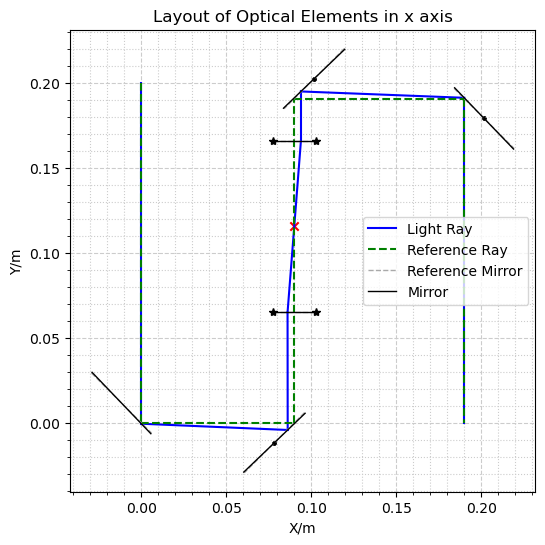

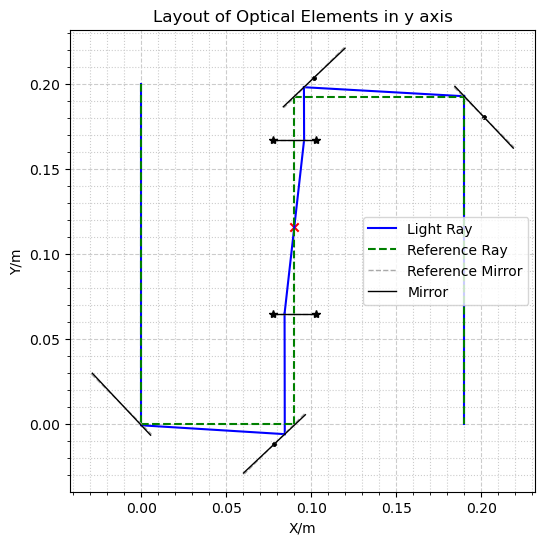

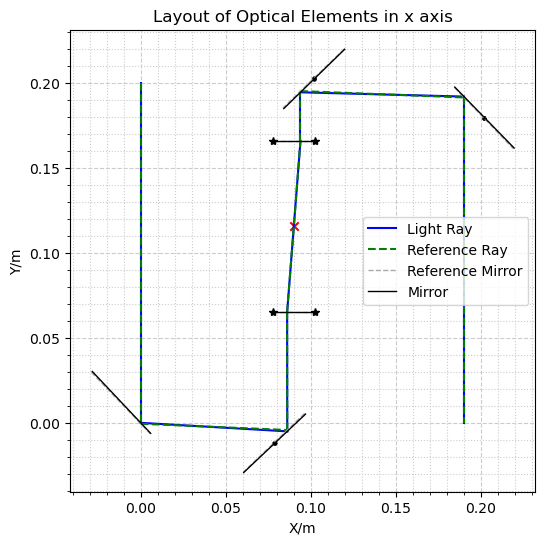

1 / 1
[[363.75134908312435, 363.7513490831102, -297.12332591670435, -297.12332591673254]]


In [6]:
x1_x = 0.09
x2_x = 0.065
dy0_x = 0.05078
dy1_x = 0.05
x4_x = 0.025
x5_x = 0.1

x1_y = 0.09
x2_y = 0.065
dy0_y = 0.05078
dy1_y = 0.0514
x4_y = 0.025
x5_y = 0.1

tl1_x_knob_deg=1000
tl1_x_n=np.arctan(tl1_x_knob_deg*(25.4)/(360*tpi*dist))
tl1_y_knob_deg=np.linspace(1440,1440,1)
#tl1_y_knob_deg=-720
tl1_y_n=np.arctan(tl1_y_knob_deg*(25.4)/(360*tpi*dist))
plot_switch=1
compensation_angles=[]
for i in range(len(tl1_y_n)):
    tls_x=four_mirror_sweep_offset(tl1_x_n,x1_x,x2_x,x4_x,x5_x,dy0_x,dy1_x,0,plot_switch)
    tls_y=four_mirror_sweep_offset(tl1_y_n[i],x1_y,x2_y,x4_y,x5_y,dy0_y,dy1_y,1,plot_switch)
    tls=np.vstack((tls_x,tls_y))
    compensation_angles.append(xy_compensation(tls,x1_x,x2_x,x4_x,x5_x,dy0_x,dy1_x,plot_switch))
    print(i+1,'/',len(tl1_y_n))
print(compensation_angles)